# Machine Learning Model Training & Evaluation

## Objective

The objective of this notebook is to train, compare, and evaluate multiple machine learning regression models for predicting the burned forest area.

This notebook includes:

- Loading the engineered dataset
- Feature selection
- Train-test split
- Data preprocessing
- Model training
- Cross-validation
- Hyperparameter tuning
- Model evaluation
- Model comparison
- Saving the best-performing model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


### Load Engineered Dataset

In [2]:
df = pd.read_csv("../../dataset/forestfires_engineered.csv")

print(df.shape)

df.head()

(513, 26)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,...,dryness_index,wind_effect,fuel_moisture_deficit,month_num,month_sin,month_cos,day_num,day_sin,day_cos,location_cluster
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,...,0.157692,54.94,0.503846,3,1.000000,6.123234e-17,5,-9.749279e-01,-0.222521,2
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,...,0.529412,16.20,1.041176,10,-0.866025,5.000000e-01,2,9.749279e-01,-0.222521,2
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,...,0.429412,18.98,1.285294,10,-0.866025,5.000000e-01,6,-7.818315e-01,0.623490,2
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,...,0.084694,33.20,0.339796,3,1.000000,6.123234e-17,5,-9.749279e-01,-0.222521,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,...,0.114000,20.52,0.513000,3,1.000000,6.123234e-17,7,-2.449294e-16,1.000000,0


### Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X                      513 non-null    int64  
 1   Y                      513 non-null    int64  
 2   month                  513 non-null    str    
 3   day                    513 non-null    str    
 4   FFMC                   513 non-null    float64
 5   DMC                    513 non-null    float64
 6   DC                     513 non-null    float64
 7   ISI                    513 non-null    float64
 8   temp                   513 non-null    float64
 9   RH                     513 non-null    int64  
 10  wind                   513 non-null    float64
 11  rain                   513 non-null    float64
 12  area                   513 non-null    float64
 13  season                 513 non-null    str    
 14  rain_present           513 non-null    int64  
 15  fire_weather_scor

In [4]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,dryness_index,wind_effect,fuel_moisture_deficit,month_num,month_sin,month_cos,day_num,day_sin,day_cos,location_cluster
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,...,513.000000,513.000000,513.000000,513.000000,513.000000,5.130000e+02,513.000000,5.130000e+02,513.000000,513.000000
mean,4.678363,4.300195,90.637427,110.989279,549.155166,9.023587,18.887524,44.348928,4.010526,0.021832,...,0.494685,73.370195,2.722302,7.485380,-0.543845,-2.180249e-01,4.251462,-5.849145e-02,0.109638,1.814815
std,2.320059,1.230925,5.540920,64.191013,247.724594,4.575543,5.828128,16.358803,1.796613,0.297107,...,0.274664,36.137404,1.759024,2.275095,0.701591,4.071255e-01,2.075038,7.075839e-01,0.696998,1.049002
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,...,0.036667,4.140000,0.010891,1.000000,-1.000000,-1.000000e+00,1.000000,-9.749279e-01,-0.900969,0.000000
25%,3.000000,4.000000,90.200000,68.600000,440.900000,6.400000,15.500000,33.000000,2.700000,0.000000,...,0.293056,46.080000,1.410000,7.000000,-1.000000,-5.000000e-01,2.000000,-7.818315e-01,-0.222521,1.000000
50%,4.000000,4.000000,91.600000,108.300000,664.500000,8.400000,19.300000,42.000000,4.000000,0.000000,...,0.443182,69.600000,2.484783,8.000000,-0.866025,-1.836970e-16,5.000000,-2.449294e-16,-0.222521,2.000000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,11.000000,22.800000,53.000000,4.900000,0.000000,...,0.632500,97.020000,3.667568,9.000000,-0.500000,-1.836970e-16,6.000000,7.818315e-01,0.623490,3.000000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,...,1.540000,213.380000,10.885000,12.000000,1.000000,1.000000e+00,7.000000,9.749279e-01,1.000000,3.000000


### Prepare Features and Target

In [7]:
# Create log-transformed target
df["target"] = np.log1p(df["area"])

X = df.drop(
    columns=[
        "area",
        "target",
        "month",
        "day",
        "season"
    ]
)

y = df["target"]

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (513, 22)
Target: (513,)


### Check Feature List

In [10]:
print(X.shape)

print(X.columns.tolist())

(513, 22)
['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'rain_present', 'fire_weather_score', 'dryness_index', 'wind_effect', 'fuel_moisture_deficit', 'month_num', 'month_sin', 'month_cos', 'day_num', 'day_sin', 'day_cos', 'location_cluster']


# Feature Importance Analysis

Before training multiple machine learning models, feature importance analysis is performed to understand which variables contribute the most to predicting burned area.

A Random Forest Regressor is used because it naturally estimates the importance of each feature based on its contribution to reducing prediction error across many decision trees.

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
6,temp,0.108606
13,wind_effect,0.107632
14,fuel_moisture_deficit,0.096383
12,dryness_index,0.075423
7,RH,0.063731
0,X,0.060135
11,fire_weather_score,0.055145
3,DMC,0.053623
4,DC,0.051863
1,Y,0.051646


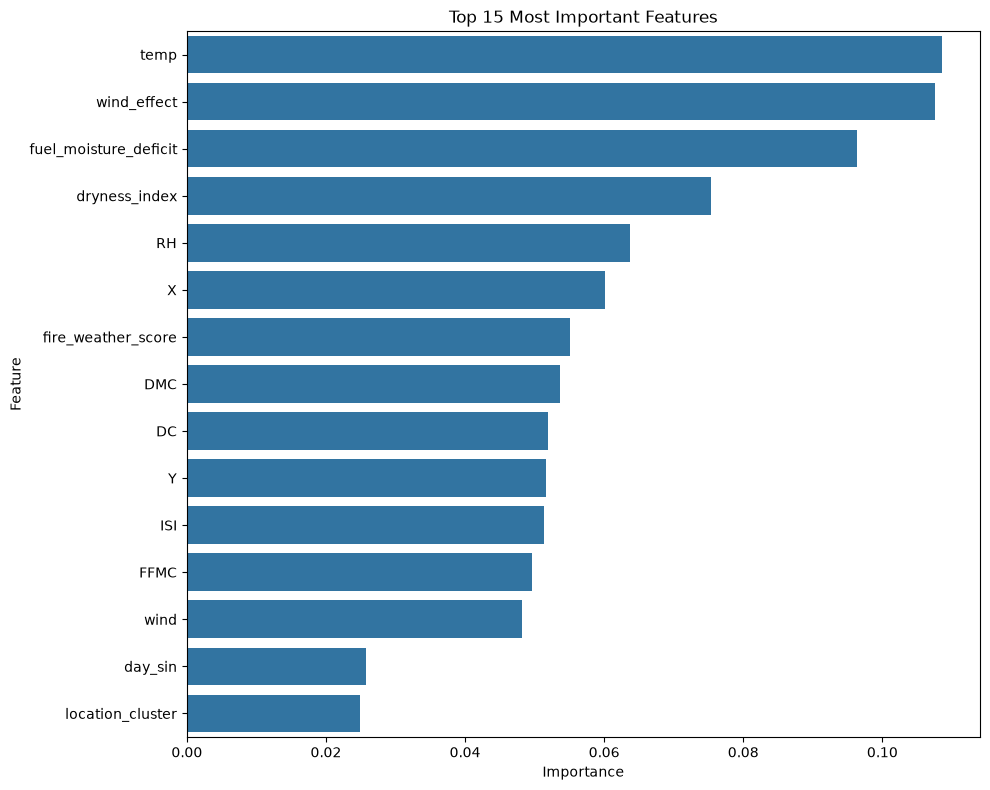

In [12]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.tight_layout()

plt.show()

## Feature Importance Analysis

A Random Forest Regressor was used to estimate the relative importance of each feature in predicting the burned forest area.

### Key Observations

- **Temperature (`temp`)** is the most influential feature, indicating that higher temperatures have a strong impact on wildfire burned area.
- **Wind Effect (`wind_effect`)** is the second most important feature, suggesting that the combination of wind speed and temperature plays a significant role in fire spread.
- **Fuel Moisture Deficit (`fuel_moisture_deficit`)** and **Dryness Index (`dryness_index`)** are also among the top predictors, highlighting the importance of vegetation dryness and moisture conditions.
- **Relative Humidity (`RH`)** contributes significantly, as lower humidity generally increases wildfire risk.
- The engineered **Fire Weather Score (`fire_weather_score`)** ranks among the important predictors, confirming that combining multiple fire weather indices provides useful predictive information.
- Spatial information, including **X**, **Y**, and **location_cluster**, also contributes to the prediction, indicating that wildfire behavior varies across different geographic regions.

### Conclusion

The feature importance analysis shows that both the original meteorological variables and the engineered features contribute to the prediction of burned area. In particular, the engineered features rank among the most important predictors, demonstrating that feature engineering successfully enhanced the dataset and is expected to improve model performance.

# Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

- **Training Set (80%)**: Used to train the machine learning models.
- **Testing Set (20%)**: Used to evaluate model performance on unseen data.

A fixed random state is used to ensure that the experiment is reproducible.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (410, 22)
Testing Features  : (103, 22)
Training Target   : (410,)
Testing Target    : (103,)


# Model Training and Comparison

Multiple regression algorithms are trained and evaluated to determine the most suitable model for predicting burned forest area.

The following models are compared:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor

Each model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- 5-Fold Cross Validation

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

### Create Models

In [15]:
models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42
    )
}

### Train Every Model

In [16]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Prediction
    prediction = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()

    results.append([
        name,
        mae,
        rmse,
        r2,
        cv
    ])

### Create Comparison Table

In [17]:
results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score",
        "CV R²"
    ]
)

results = results.sort_values(
    by="R² Score",
    ascending=False
)

results

,Model,MAE,RMSE,R² Score,CV R²
2,Lasso Regression,1.139424,1.301170,-0.013462,-0.007659
1,Ridge Regression,1.089267,1.309388,-0.026304,-0.061811
0,Linear Regression,1.091308,1.313817,-0.033259,-0.066566
4,Random Forest,1.170498,1.363787,-0.113352,-0.141502
6,Extra Trees,1.164917,1.394811,-0.164582,-0.253188
5,Gradient Boosting,1.186691,1.477690,-0.307092,-0.209489
3,Decision Tree,1.425407,1.955132,-1.288187,-1.248425


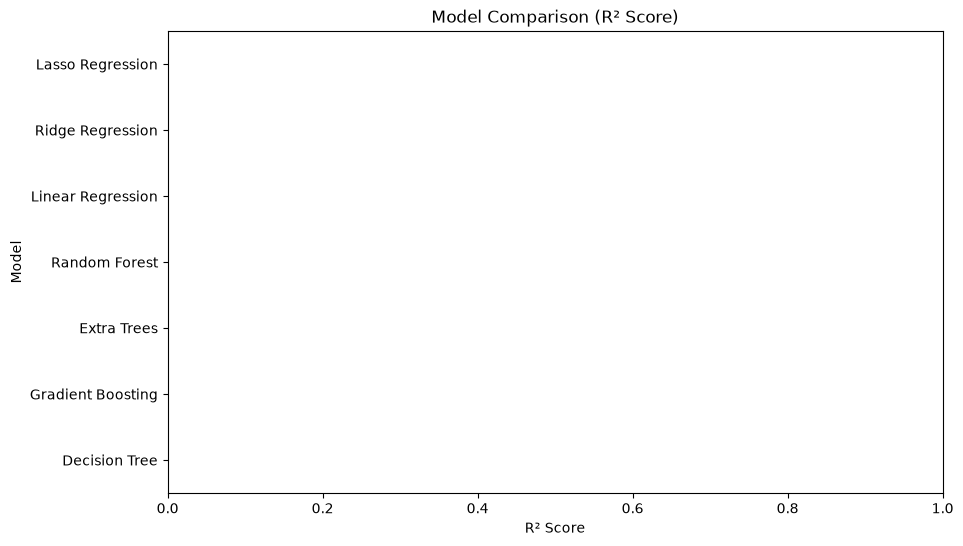

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="R² Score",
    y="Model"
)

plt.title("Model Comparison (R² Score)")

plt.xlim(0,1)

plt.show()

## Initial Random Forest Evaluation

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train R² :", rf.score(X_train, y_train))
print("Test R²  :", rf.score(X_test, y_test))

Train R² : 0.8408524803353634
Test R²  : -0.111842627326596


### Interpretation

The baseline Random Forest model achieved a training R² score of **0.841** but a testing R² score of **-0.112**.

The high training score indicates that the model learned the training data well. However, the negative testing R² score shows that it failed to generalize to unseen data and performed worse than predicting the average target value.

This suggests that the baseline Random Forest model is overfitting the training data. Therefore, further model tuning and optimization are required to improve its generalization performance.

## Hyperparameter Tuning (Random Forest)

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [35]:
rf = RandomForestRegressor(
    random_state=42
)

In [36]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,

In [37]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best Cross Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

Best Cross Validation R²:
-0.08478057416303444


In [38]:
best_rf = grid_search.best_estimator_

print("Train R² :", best_rf.score(X_train, y_train))
print("Test R²  :", best_rf.score(X_test, y_test))

Train R² : 0.5170320663586638
Test R²  : -0.02926939954338814


### Interpretation

Hyperparameter tuning was applied using GridSearchCV to optimize the Random Forest model.

The best model used the following parameters:
- max_depth = 10
- min_samples_split = 10
- min_samples_leaf = 4
- n_estimators = 500

Compared to the baseline model, the tuned Random Forest reduced overfitting. The training R² score decreased from 0.841 to 0.517, while the testing R² score improved from -0.112 to -0.029. Although the model still did not achieve a positive R² score on the test data, the results indicate better generalization to unseen data.

These findings suggest that hyperparameter tuning improved model stability, but predicting burned area remains challenging due to the highly skewed target distribution and the large number of zero burned-area observations in the dataset.